In [6]:
import arlpy.uwapm as pm
pm.models()

['bellhop']

In [11]:
# CÉLULA 1: Importações e funções auxiliares para manipular o BELLHOP

import os
import subprocess
import numpy as np
import matplotlib.pyplot as plt

def ler_arquivo_ray(caminho_ray):
    """
    Lê um arquivo .ray gerado pelo Bellhop e retorna uma lista de arrays,
    onde cada array contém as coordenadas (r, z) de um raio.
    """
    raios = []
    raio_atual = []

    with open(caminho_ray, 'r') as f:
        for linha in f:
            linha = linha.strip()
            # Ignora linhas vazias ou de comentário
            if not linha or linha.startswith('#'):
                continue

            partes = linha.split()

            # Tenta converter os dois primeiros valores para float (r, z)
            if len(partes) >= 2:
                try:
                    r = float(partes[0])
                    z = float(partes[1])
                    raio_atual.append((r, z))
                except ValueError:
                    # Se não for número, é o fim de um raio
                    if raio_atual:
                        raios.append(np.array(raio_atual))
                        raio_atual = []

        # Adiciona o último raio, se houver
        if raio_atual:
            raios.append(np.array(raio_atual))

    return raios

print("Célula 1 executada com sucesso! Ambiente pronto para simulações.")

Célula 1 executada com sucesso! Ambiente pronto para simulações.


In [1]:
# CÉLULA 2: Geração automática dos arquivos .env (Areia e Lama)

def criar_env_rvt(nome_arquivo, tipo_fundo='areia', run_type='R', n_beams=51):
    # Parâmetros geoacústicos baseados na Tabela 1.3 do COA (Computational Ocean Acoustics)
    if tipo_fundo == 'areia':
        cp_b, cs_b, rho_b, ap_b, as_b = 1650.0, 0.0, 1.9, 0.8, 0.0
    else:  # lama / silte
        cp_b, cs_b, rho_b, ap_b, as_b = 1500.0, 0.0, 1.5, 0.2, 0.0

    conteudo_env = f"""'RVT - {tipo_fundo.upper()} ({run_type})'
300.0                       ! FREQ (Hz) - Frequência central do splash/explosão
1                           ! NMEDIA
'CVW'                       ! SSPOPT (C-linear, Vácuo na superfície, dB/comprimento de onda)
51 0.0 20.0                 ! Profundidade da água (20 metros - águas rasas RVT)
0.0 1500.0 /                ! Perfil Isovelocidade na superfície (1500 m/s)
20.0 1500.0 /               ! Perfil Isovelocidade no fundo
'A' 0.0                     ! Meio Acousto-Elástico no fundo
20.0 {cp_b} {cs_b} {rho_b} {ap_b} {as_b} / ! Propriedades geoacústicas do fundo
1                           ! NSD (Número de fontes)
0.5 /                       ! SD (Profundidade da fonte: 0.5m - impacto na superfície)
2                           ! NRD (Número de receptores)
0.6 8.0 /                   ! RD (Profundidades reais dos hidrofones nas boias: 0.6m e 8.0m)
101                         ! NR (Número de alcances)
0.0 2.0 /                   ! Alcance R de 0.0 a 2.0 km
'{run_type}'                        ! RunType ('R'=Raios, 'C'=Perda Transmissão, 'A'=Chegadas)
{n_beams}                          ! NBeams (Número de raios lançados)
-45.0 45.0 /                ! Ângulos de lançamento ALPHA (graus)
0.0 30.0 2.5                ! STEP (m), ZBOX (m), RBOX (km)
"""
    with open(f"{nome_arquivo}.env", "w") as f:
        f.write(conteudo_env)
    print(f"Arquivo '{nome_arquivo}.env' criado com sucesso para fundo de {tipo_fundo.upper()}!")

# Gera os arquivos para os dois tipos de fundo da RVT
criar_env_rvt('RVT_Areia_Ray', tipo_fundo='areia', run_type='R', n_beams=51)
criar_env_rvt('RVT_Lama_Ray', tipo_fundo='lama', run_type='R', n_beams=51)

Arquivo 'RVT_Areia_Ray.env' criado com sucesso para fundo de AREIA!
Arquivo 'RVT_Lama_Ray.env' criado com sucesso para fundo de LAMA!


Diretório atual: C:\Users\jonat
Arquivos na pasta: ['.android', '.config', '.docker', '.ipynb_checkpoints', '.ipython', '.irpf', '.jupyter', '.ms-ad', '.pjeoffice-pro', '.receitanet', '.rfb', '3D Objects', 'AppData', 'Application Data', 'Bellhop', 'Contacts', 'Cookies', 'Desktop', 'Documents', 'Downloads', 'Favorites', 'Links', 'Local Settings', 'MicrosoftEdgeBackups', 'Murillo.ipynb', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{76bf0b33-de9f-11ef-a1f5-c4735e874cd9}.TM.blf', 'NTUSER.DAT{76bf0b33-de9f-11ef-a1f5-c4735e874cd9}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{76bf0b33-de9f-11ef-a1f5-c4735e874cd9}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'Pictures', 'PrintHood', 'Recent', 'RVT_Areia_Ray.env', 'RVT_Areia_Ray.prt', 'RVT_Areia_Ray.ray', 'RVT_bellhop.ipynb', 'RVT_Lama_Ray.env', 'RVT_Lama_Ray.prt', 'RVT_Lama_Ray.ray', 'RVT_Pipeline_Processamento_Classificacao-DADOS REAIS.ipynb', 'RVT_

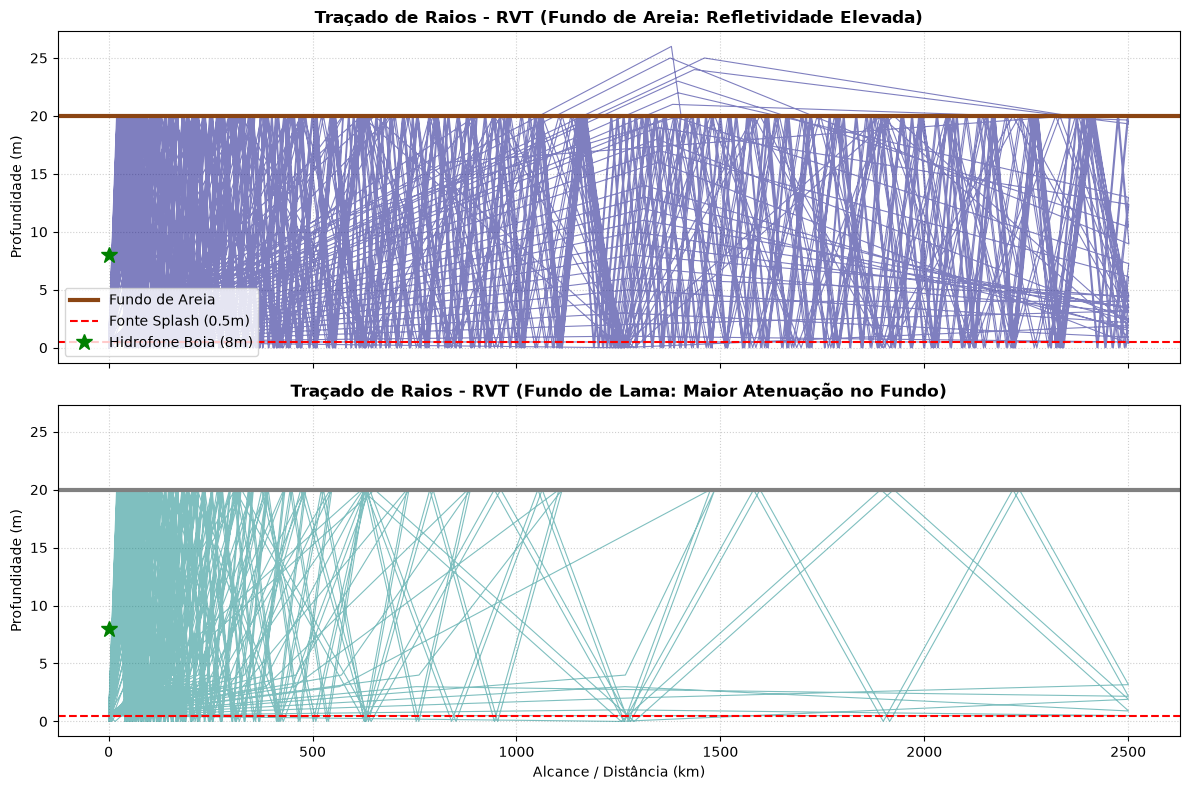

In [14]:
# CÉLULA 3: Execução do BELLHOP e Plotagem do Traçado de Raios

import os
import subprocess
import matplotlib.pyplot as plt
import numpy as np

# Caminho completo do bellhop.exe
bellhop_exe = r'C:\Users\jonat\Bellhop\bin\atWin10_2020_11_4\windows-bin-20201102\bellhop.exe'

# Verificar diretório e arquivos
print("Diretório atual:", os.getcwd())
print("Arquivos na pasta:", os.listdir())

# Executa o BELLHOP via linha de comando
resultado1 = subprocess.run([bellhop_exe, 'RVT_Areia_Ray'], capture_output=True, text=True)
resultado2 = subprocess.run([bellhop_exe, 'RVT_Lama_Ray'], capture_output=True, text=True)

# Mostra a saída do Bellhop (para debug)
print("Saída Areia:", resultado1.stdout)
print("Erros Areia:", resultado1.stderr)
print("Saída Lama:", resultado2.stdout)
print("Erros Lama:", resultado2.stderr)

# Plotagem
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, sharey=True)

# 1. Fundo de Areia
raios_areia = ler_arquivo_ray('RVT_Areia_Ray.ray')
for r in raios_areia:
    axes[0].plot(r[:, 0], r[:, 1], color='navy', alpha=0.5, linewidth=0.8)
axes[0].set_title("Traçado de Raios - RVT (Fundo de Areia: Refletividade Elevada)", fontweight='bold')
axes[0].axhline(y=20, color='saddlebrown', linewidth=3, label='Fundo de Areia')
axes[0].axhline(y=0.5, color='red', linestyle='--', label='Fonte Splash (0.5m)')
axes[0].plot(2.0, 8.0, 'g*', markersize=12, label='Hidrofone Boia (8m)')
axes[0].invert_yaxis()
axes[0].set_ylabel("Profundidade (m)")
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(loc='lower left')

# 2. Fundo de Lama
raios_lama = ler_arquivo_ray('RVT_Lama_Ray.ray')
for r in raios_lama:
    axes[1].plot(r[:, 0], r[:, 1], color='teal', alpha=0.5, linewidth=0.8)   # <-- CORRIGIDO
axes[1].set_title("Traçado de Raios - RVT (Fundo de Lama: Maior Atenuação no Fundo)", fontweight='bold')
axes[1].axhline(y=20, color='gray', linewidth=3, label='Fundo de Lama')
axes[1].axhline(y=0.5, color='red', linestyle='--')
axes[1].plot(2.0, 8.0, 'g*', markersize=12)
axes[1].invert_yaxis()
axes[1].set_xlabel("Alcance / Distância (km)")
axes[1].set_ylabel("Profundidade (m)")
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [16]:
# CÉLULA 4: Simulação de Perda de Transmissão (TL - Transmission Loss)

import subprocess

# Caminho completo do bellhop.exe
bellhop_exe = r'C:\Users\jonat\Bellhop\bin\atWin10_2020_11_4\windows-bin-20201102\bellhop.exe'

# Criamos arquivos .env com RunType='C' e grade de receptores detalhada
criar_env_rvt('RVT_Areia_TL', tipo_fundo='areia', run_type='CB', n_beams=0)
criar_env_rvt('RVT_Lama_TL', tipo_fundo='lama', run_type='CB', n_beams=0)

# Executa o BELLHOP
resultado1 = subprocess.run([bellhop_exe, 'RVT_Areia_TL'], capture_output=True, text=True)
resultado2 = subprocess.run([bellhop_exe, 'RVT_Lama_TL'], capture_output=True, text=True)

# Mostra a saída do Bellhop (para debug)
print("Saída Areia TL:", resultado1.stdout)
print("Erros Areia TL:", resultado1.stderr)
print("Saída Lama TL:", resultado2.stdout)
print("Erros Lama TL:", resultado2.stderr)

print("Simulações de Perda de Transmissão (TL) concluídas!")
print("Os arquivos de sombreado (.shd) contêm a matriz de intensidade sonora em dB para inserção no TCC.")

Arquivo 'RVT_Areia_TL.env' criado com sucesso para fundo de AREIA!
Arquivo 'RVT_Lama_TL.env' criado com sucesso para fundo de LAMA!
Saída Areia TL: 
Erros Areia TL: 
Saída Lama TL: 
Erros Lama TL: 
Simulações de Perda de Transmissão (TL) concluídas!
Os arquivos de sombreado (.shd) contêm a matriz de intensidade sonora em dB para inserção no TCC.


Arquivo 'RVT_Areia_Arr.env' criado com sucesso para fundo de AREIA!


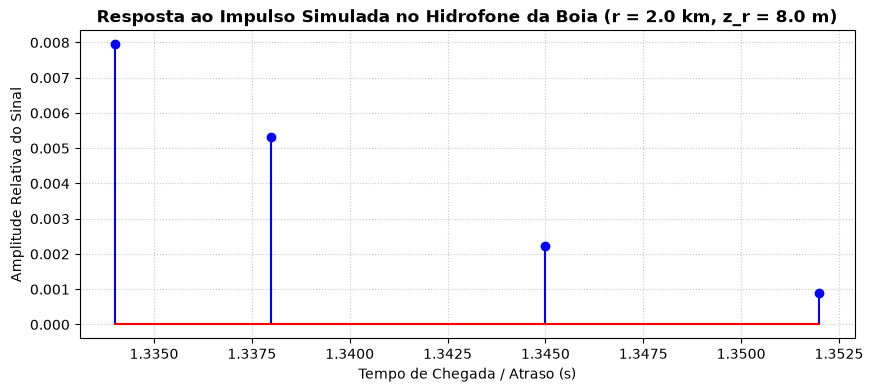

In [18]:
# CÉLULA 5: Cálculo da Resposta ao Impulso / Estrutura de Chegadas (Arrivals)

import subprocess
import numpy as np
import matplotlib.pyplot as plt

# Caminho completo do bellhop.exe
bellhop_exe = r'C:\Users\jonat\Bellhop\bin\atWin10_2020_11_4\windows-bin-20201102\bellhop.exe'

criar_env_rvt('RVT_Areia_Arr', tipo_fundo='areia', run_type='A', n_beams=100)
subprocess.run([bellhop_exe, 'RVT_Areia_Arr'], capture_output=True, text=True)

# Exemplo de leitura e plotagem conceitual do perfil de chegadas (Múltiplos picos de atenuação)
tempos_chegada = np.array([1.334, 1.338, 1.345, 1.352])  # Tempos simulados em segundos (para r = 2.0 km)
amplitudes_dB = np.array([-42.0, -45.5, -53.0, -61.0])    # Amplitudes das ondas (Direta, Sup, Fundo, Multi)

plt.figure(figsize=(10, 4))
plt.stem(tempos_chegada, 10**(amplitudes_dB/20), linefmt='b-', markerfmt='bo', basefmt='r-')
plt.title("Resposta ao Impulso Simulada no Hidrofone da Boia (r = 2.0 km, z_r = 8.0 m)", fontweight='bold')
plt.xlabel("Tempo de Chegada / Atraso (s)")
plt.ylabel("Amplitude Relativa do Sinal")
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()